In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import kagglehub
import glob
from sklearn.model_selection import train_test_split
path = kagglehub.dataset_download("greatgamedota/culane")





In [3]:
print(path)

/kaggle/input/datasets/greatgamedota/culane


In [4]:


images = sorted(glob.glob(os.path.join(path, '**','*.jpg'),recursive=True))
masks = sorted(glob.glob(os.path.join(path, '**','*.png'),recursive=True))

print(len(images))
print(len(masks))


18233
18233


In [5]:
train_images, test_images, train_masks, test_masks = train_test_split(images, masks, test_size=0.2, random_state=42)
val_images, test_images, val_masks, test_masks = train_test_split(test_images, test_masks, test_size=0.5, random_state=42)

print(f'Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}')

Train: 14586, Val: 1823, Test: 1824


In [6]:
def preprocess_data(img_path, msk_path, target_size=(256,256)):
    # معالجة الصورة
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0
    

    mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    
 
    mask = np.expand_dims(mask, axis=-1) 
    mask = (mask > 0).astype(np.float32)   
    
    return img, mask

In [7]:
def data_generator(img_path, msk_path, batch_size=16, target_size=(256,256)):
    while True:
        for i in range(0, len(img_path), batch_size):
            batch_img_path = img_path[i : i + batch_size]
            batch_msk_path = msk_path[i : i + batch_size]

            batch_x = []
            batch_y = []

            for img_p, msk_p in zip(batch_img_path, batch_msk_path):
                img, processed_mask = preprocess_data(img_p, msk_p, target_size)
                
                batch_x.append(img)
                batch_y.append(processed_mask)

            yield np.array(batch_x), np.array(batch_y)

In [8]:
train_gen = data_generator(train_images, train_masks, batch_size=16)
val_gen = data_generator(val_images, val_masks, batch_size=16)


In [9]:
from tensorflow.keras import layers, models
def build_model(input_shape=(256,256,3)):
  inputs = layers.Input(input_shape)

  #Encode
  c1 = layers.Conv2D(64,(3,3), activation='relu', padding='same')(inputs)

  c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
  p1 = layers.MaxPooling2D((2,2))(c1)

  c2 = layers.Conv2D(128,(3,3), activation='relu', padding='same')(p1)
  c2 = layers.Conv2D(128,(3,3), activation='relu', padding='same')(c2)
  p2 = layers.MaxPooling2D((2,2))(c2)

  c3 = layers.Conv2D(256,(3,3), activation='relu', padding='same')(p2)
  c3 = layers.Conv2D(256,(3,3), activation='relu', padding='same')(c3)

  #decode
  u4 = layers.UpSampling2D((2,2))(c3)
  u4 = layers.concatenate([u4, c2])

  c4 = layers.Conv2D(128,(3,3), activation='relu', padding='same')(u4)

  u5 = layers.UpSampling2D((2,2))(c4)
  u5 = layers.concatenate([u5,c1])
  c5 = layers.Conv2D(64,(3,3), activation='relu', padding='same')(u5)

  output = layers.Conv2D(1,(1,1), activation='sigmoid')(c5)

  model = models.Model(inputs=[inputs], outputs=[output])
  return model

model = build_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

2026-04-25 19:43:19.732124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777146200.245134      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777146200.362933      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777146201.398084      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777146201.398135      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777146201.398137      55 computation_placer.cc:177] computation placer alr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │         65 │ conv2d_7[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,698,625 (6.48 MB)

 Trainable params: 1,698,625 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import tensorflow as tf
steps_per_epoch = len(train_images) // 16
val_steps = len(val_images) // 16
checkpoint = tf.keras.callbacks.ModelCheckpoint('autoDrive_bes.keras', monitor='val_loss', save_best_only=True)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    epochs=3,
    callbacks=checkpoint
    )

Epoch 1/3


I0000 00:00:1777146241.829045     127 service.cc:152] XLA service 0x79346c00e1c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777146241.829087     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777146241.829093     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777146242.578108     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 19:44:23.860858: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 19:44:24.162470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 19:44:25.542928: E external/local_xl

911/911 ━━━━━━━━━━━━━━━━━━━━ 556s 559ms/step - accuracy: 0.9679 - loss: 0.1146 - val_accuracy: 0.9784 - val_loss: 0.0707
Epoch 2/3


2026-04-25 19:53:19.426067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 19:53:19.656852: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 19:53:20.936775: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 19:53:21.247139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 19:53:31.907890: E external/local_xla/xla/stream_

911/911 ━━━━━━━━━━━━━━━━━━━━ 444s 450ms/step - accuracy: 0.9790 - loss: 0.0686 - val_accuracy: 0.9808 - val_loss: 0.0606
Epoch 3/3
911/911 ━━━━━━━━━━━━━━━━━━━━ 410s 450ms/step - accuracy: 0.9809 - loss: 0.0602 - val_accuracy: 0.9817 - val_loss: 0.0563


In [11]:
test_gen = data_generator(test_images,test_masks, batch_size=16)

loss, accuracy = model.evaluate(test_gen,steps= len(test_images) // 16)
print(f'accuracy: {accuracy * 100:.2f}')

114/114 ━━━━━━━━━━━━━━━━━━━━ 55s 489ms/step - accuracy: 0.9818 - loss: 0.0558
accuracy: 98.15


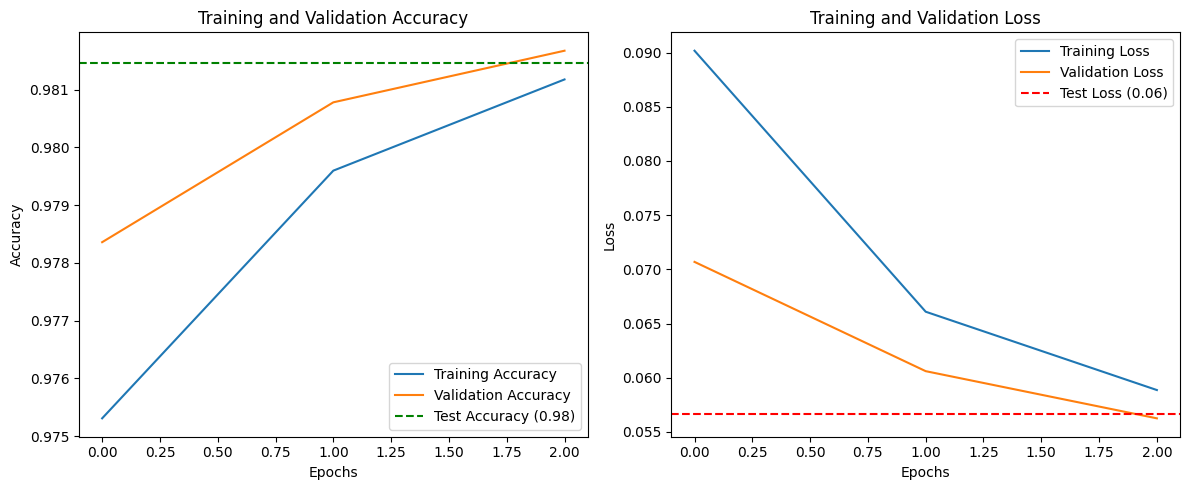

In [12]:
acc = history.history['accuracy']
lossT = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axhline(y=accuracy, color='g', linestyle='--', label=f'Test Accuracy ({accuracy:.2f})')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, lossT, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axhline(y=loss, color='r', linestyle='--', label=f'Test Loss ({loss:.2f})')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [13]:
import cv2 
def predict_lanne(model, image_path, target_size=(256,256)):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resize = cv2.resize(img_rgb, target_size)
    img_normalized = img_resize / 255.0

    input_data = np.expand_dims(img_normalized, axis=0)

    prediction = model.predict(input_data)[0]

    mask = (prediction > 0.5).astype(np.uint8)

    return img_resize, mask

2026-04-25 20:08:27.994856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 20:08:28.196210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 20:08:28.695585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 20:08:28.954450: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


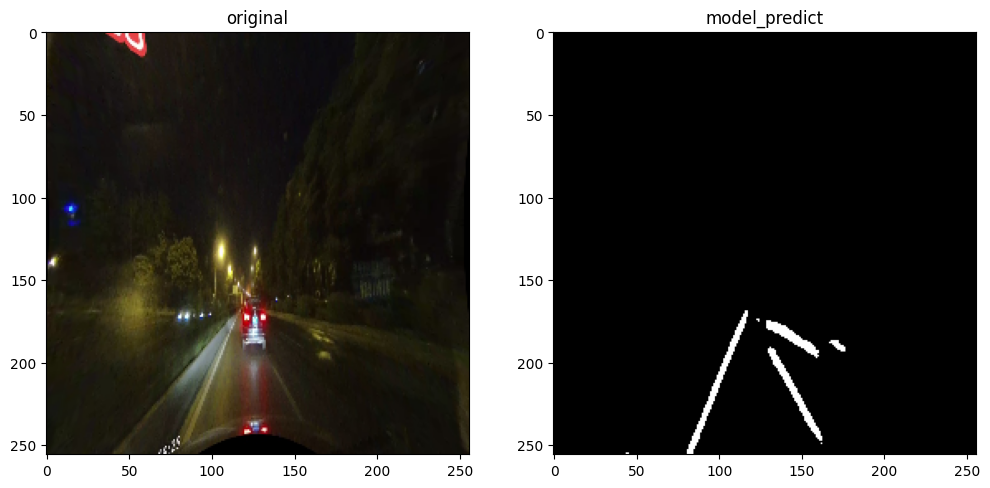

In [14]:
test_img_path = test_images[5]

original, predicted_mask = predict_lanne(model, test_img_path)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title('original')

plt.subplot(1,2,2)
plt.imshow(predicted_mask.squeeze(), cmap='gray')
plt.title('model_predict')

plt.show()

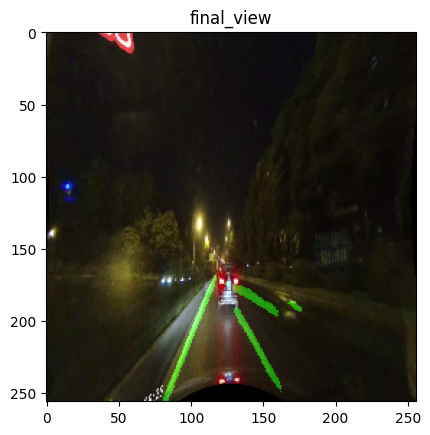

In [15]:
def over_lay(image, mask, color=(0, 255, 0)):
    mask_colored = np.zeros_like(image)
    mask_colored[mask.squeeze() == 1] = color

    output = cv2.addWeighted(image, 1.0, mask_colored, 0.5, 0)
    return output

final_view = over_lay(original, predicted_mask)
plt.imshow(final_view)
plt.title('final_view')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step


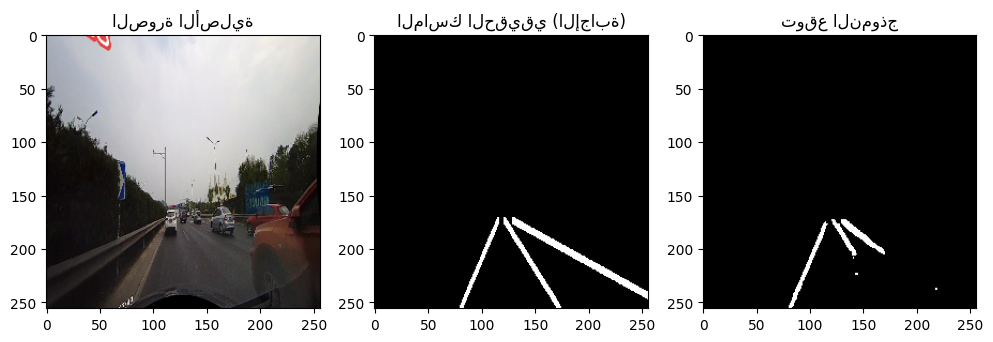

In [16]:
test_img, test_mask = next(val_gen)

prediction = model.predict(test_img)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(test_img[0])
plt.title("الصورة الأصلية")

plt.subplot(1, 3, 2)
plt.imshow(test_mask[0].squeeze(), cmap='gray')
plt.title("الماسك الحقيقي (الإجابة)")

plt.subplot(1, 3, 3)
plt.imshow(prediction[0].squeeze() > 0.5, cmap='gray')
plt.title("توقع النموذج")

plt.show()